# CWT Visualization — Standalone

This notebook reproduces the CWT (Continuous Wavelet Transform) visualization
from the main analysis notebook **without** requiring the full STEAD/INSTANCE
dataset to be downloaded.

All you need is:
- This notebook
- The file `cwt_sample_data.npz` (placed in the same directory)
- `pip install numpy scipy matplotlib seaborn`


In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import fftconvolve
from matplotlib.ticker import ScalarFormatter


In [2]:
# ── Load the pre-exported trace and metadata ──────────────────────────────
# The file cwt_sample_data.npz was generated by export_cwt_data.py on a
# machine that has the INSTANCE dataset downloaded.

data = np.load("../dataset/cwt_sample_data.npz", allow_pickle=True)
trace = data["trace"]
metadata = json.loads(str(data["metadata_json"]))

print(f"Trace shape: {trace.shape}")
print(f"Metadata: {metadata}")


Trace shape: (12000,)
Metadata: {'trace_sampling_rate_hz': 100.0, 'trace_P_arrival_sample': 1828.0, 'trace_S_arrival_sample': 2143.0}


In [4]:
def apply_cwt(trace, sf=100.0, num_bins=32, f_min=0.5, f_max=45.0, B=1.5, C=1.0):
    """
    Applies a Complex Morlet CWT to a raw NumPy array at its ORIGINAL time resolution.
    """
    is_1d = trace.ndim == 1
    trace_2d = np.atleast_2d(trace)
    num_channels, seq_len = trace_2d.shape

    freqs = np.logspace(np.log10(f_min), np.log10(f_max), num_bins)
    scales = C / (freqs * (1.0 / sf))

    max_scale = scales[0]
    window_len = int(10 * max_scale)
    if window_len % 2 == 0:
        window_len += 1

    t = np.arange(-window_len // 2 + 1, window_len // 2 + 1)

    cwt_mag = np.zeros((num_channels, num_bins, seq_len), dtype=np.float32)

    for i, s in enumerate(scales):
        x = t / s
        norm = 1.0 / np.sqrt(np.pi * B)
        gauss = np.exp(-(x**2) / B)

        real_w = norm * np.cos(2 * np.pi * C * x) * gauss / np.sqrt(s)
        imag_w = norm * np.sin(2 * np.pi * C * x) * gauss / np.sqrt(s)

        for ch in range(num_channels):
            real_out = fftconvolve(trace_2d[ch], real_w, mode="same")
            imag_out = fftconvolve(trace_2d[ch], imag_w, mode="same")
            cwt_mag[ch, i, :] = np.sqrt(real_out**2 + imag_out**2)

    times = np.arange(seq_len) / sf
    out_mag = cwt_mag[0] if is_1d else cwt_mag
    return out_mag, freqs, times


In [57]:
def visualize_seismic_cwt(trace, cwt_data, freqs, times,
                          p_arrival=None, s_arrival=None,
                          title="Seismic Trace CWT Analysis"):
    sns.set_theme(style="whitegrid")

    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 2],
                         width_ratios=[40, 1], hspace=0.05, wspace=0.02)

    ax_sig  = fig.add_subplot(gs[0, 0])
    ax_spec = fig.add_subplot(gs[1, 0])
    ax_cbar = fig.add_subplot(gs[1, 1])

    # Raw signal
    ax_sig.plot(times, trace, color="#4c72b0", linewidth=1.0)
    ax_sig.set_ylabel("Amplitude")
    ax_sig.set_title(title, loc="center", fontweight="bold", fontsize=14, pad=15)
    ax_sig.set_xlim(times[0], times[-1])
    plt.setp(ax_sig.get_xticklabels(), visible=False)

    # CWT heatmap
    img = ax_spec.pcolormesh(times, freqs, cwt_data, cmap="rocket", shading="gouraud")
    ax_spec.set_yscale("log")
    tick_values = [0.25, 0.5, 1, 2, 4, 8, 16, 32, 64, 128]
    ax_spec.set_yticks(tick_values)
    ax_spec.yaxis.set_major_formatter(ScalarFormatter())
    ax_spec.set_ylabel("Frequency (Hz)")
    ax_spec.set_xlabel("Time (s)")
    ax_spec.set_ylim(freqs.min(), freqs.max())

    # Colorbar
    cbar = fig.colorbar(img, cax=ax_cbar)
    cbar.set_label("Log Amplitude", rotation=270, labelpad=15)

    # Arrival lines
    arrivals = [(p_arrival, "P", "#5ae622"), (s_arrival, "S", "#3c1dd4")]
    for arr_time, label, color in arrivals:
        if arr_time is not None:
            for ax in [ax_sig, ax_spec]:
                ax.axvline(x=arr_time, color=color, linestyle="-",
                           linewidth=2, alpha=0.5)
            ax_sig.text(arr_time, ax_sig.get_ylim()[1], f" {label}",
                        color=color, fontweight="bold", va="bottom")

    plt.subplots_adjust(hspace=0.05)
    return fig


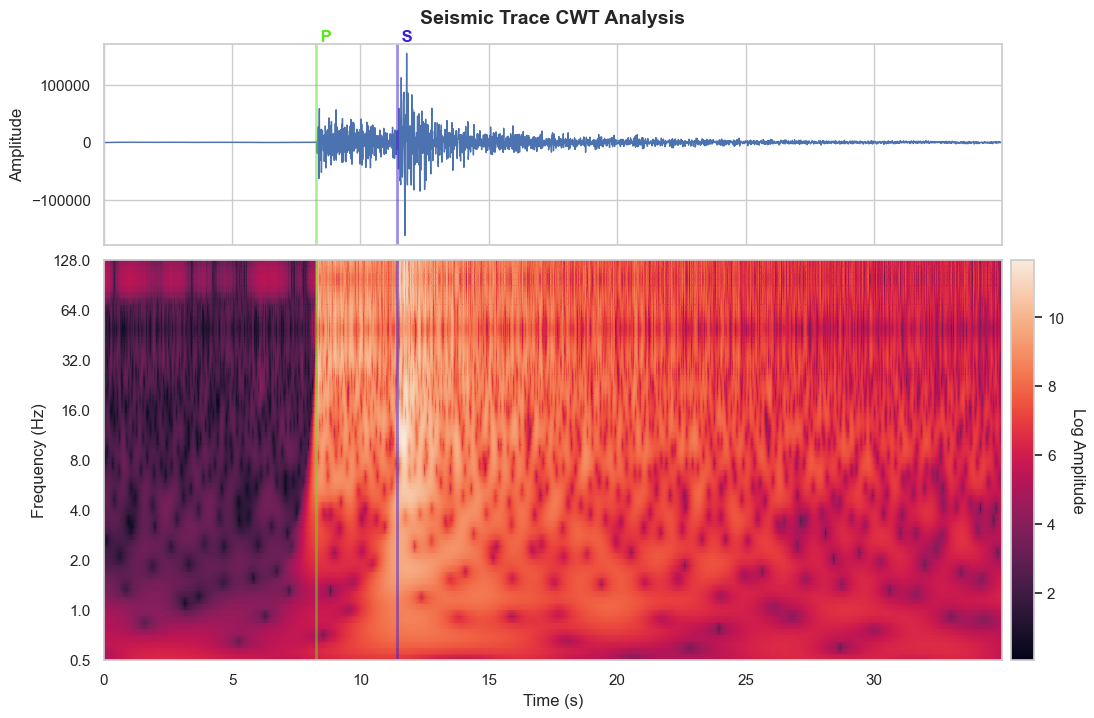

In [58]:
# ── Run the CWT visualization ─────────────────────────────────────────────

sr = int(metadata["trace_sampling_rate_hz"])
p_arrival_time = metadata["trace_P_arrival_sample"] / sr
s_arrival_time = metadata["trace_S_arrival_sample"] / sr
low = 10
high = 45

cwt_mag, freqs, times = apply_cwt(trace, sr, num_bins=64, f_min=0.5, f_max=128)
log_cwt_numpy = np.log1p(cwt_mag)

times_plot = times[low*sr:high*sr]
cut_time = times_plot[0]
times_plot = times_plot - cut_time
p_arrival_time = p_arrival_time - cut_time
s_arrival_time = s_arrival_time - cut_time


fig = visualize_seismic_cwt(
    trace[low*sr:high*sr], log_cwt_numpy[:, low*sr:high*sr], freqs, times_plot,
    p_arrival_time, s_arrival_time
)
plt.savefig("cwt_viz.png")
plt.show()
